In [ ]:
import os

from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph.message import add_messages
from langchain_core.messages import BaseMessage,HumanMessage
from langchain_groq import ChatGroq
from typing import List, Annotated, TypedDict

from dotenv import load_dotenv

load_dotenv()


True

In [2]:
llm = ChatGroq(model=os.getenv('GROQ_MODEL'),api_key=os.getenv('GROQ_API_KEY'), temperature=0.2)

In [3]:
class ChatState(TypedDict):

    messages: Annotated[List[BaseMessage], add_messages]

In [4]:
def chat_message(state: ChatState):

    messages= state['messages']

    response = llm.invoke(messages)

    return {"messages":[response]}

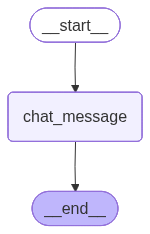

In [5]:
checkpointer = MemorySaver()

graph = StateGraph(ChatState)

graph.add_node('chat_message',chat_message)

graph.add_edge(START, 'chat_message')
graph.add_edge('chat_message',END)

workflow = graph.compile(checkpointer=checkpointer)

workflow


In [6]:
thread_id = 1
config  = {"configurable":{"thread_id": thread_id}}

while True:

    user_message = input("User Message: ")

    print("User Message: ",user_message)

    if user_message.strip().lower() in ['quit', 'bye','close','exit','adios'] :
        break
    else:
        llm_response  = workflow.invoke({"messages": [HumanMessage(user_message)]}, config=config)
        print("LLM Response: ", llm_response['messages'][-1].content)

User Message:  hello
LLM Response:  Hello. How can I assist you today?
User Message:  what is your name?
LLM Response:  I'm an AI assistant, and I don't have a personal name. I'm often referred to as a "chatbot" or a "virtual assistant." If you'd like, I can suggest some names for our conversation, or we can just stick with a simple greeting. How would you like to address me?
User Message:  your name is Kira
LLM Response:  From now on, I'll respond as Kira. It's nice to have a name, even if it's just for our conversation. Hello again! I'm Kira, your friendly AI assistant. How can I help you today?
User Message:  what was your name again?
LLM Response:  My name is Kira. You gave it to me earlier in our conversation. I'm glad you reminded me!
User Message:  quit
